In [7]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU count: 2


In [10]:
!pip install -q diffusers transformers accelerate safetensors huggingface_hub gradio

In [11]:
import diffusers
import transformers
import accelerate
import gradio

print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("gradio:", gradio.__version__)
print("All libraries imported successfully!")

diffusers: 0.40.0
transformers: 5.16.1
accelerate: 1.14.0
gradio: 6.26.0
All libraries imported successfully!


In [3]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

print("Loading Realistic Vision V5.1...")

realistic_pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V5.1_noVAE",
    torch_dtype=torch.float16,
    safety_checker=None
)

realistic_pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    realistic_pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    final_sigmas_type="sigma_min"
)

realistic_pipe = realistic_pipe.to("cuda")

print("Realistic Vision V5.1 loaded successfully!")
print("Device:", realistic_pipe.device)

Loading Realistic Vision V5.1...


/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Realistic Vision V5.1 loaded successfully!
Device: cuda:0


In [5]:
pipe = realistic_pipe

print("Pipeline connected successfully!")
print("Device:", pipe.device)

Pipeline connected successfully!
Device: cuda:0


  0%|          | 0/30 [00:00<?, ?it/s]

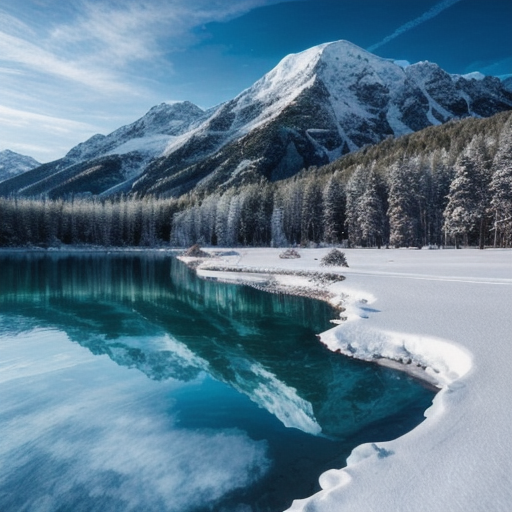

In [15]:
from IPython.display import display

test_prompt = (
    "A beautiful mountain landscape with snow-covered mountains, "
    "a clear blue lake, green trees, blue sky, "
    "cinematic landscape photography, photorealistic"
)

test_image = pipe(
    test_prompt,
    height=512,
    width=512,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

display(test_image)

In [13]:
import gradio as gr
import time

def generate_image(prompt, num_inference_steps=35, guidance_scale=7.5):

    if not prompt or not prompt.strip():
        return None

    original_prompt = prompt.strip()
    prompt_lower = original_prompt.lower()

    # Detect full-body human prompts
    full_body_keywords = [
        "full body",
        "full-body",
        "head to toe",
        "head-to-toe",
        "entire body",
        "entire person",
        "standing naturally",
        "walking naturally"
    ]

    is_full_body = any(
        keyword in prompt_lower
        for keyword in full_body_keywords
    )

    # ============================================================
    # FULL-BODY HUMAN
    # ============================================================
    if is_full_body and any(
        word in prompt_lower
        for word in ["woman", "girl", "man", "boy", "person", "human"]
    ):

        enhanced_prompt = (
            f"{original_prompt}, "
            "photorealistic real human, "
            "extremely realistic natural human face, "
            "accurate facial proportions, symmetrical natural face, "
            "realistic eyes with detailed irises and natural pupils, "
            "realistic eyebrows, realistic nose and lips, "
            "subtle natural skin pores, fine skin texture, "
            "natural skin color variations, subtle facial imperfections, "
            "individual natural hair strands, "
            "authentic human facial structure, "
            "natural expression, "
            "realistic anatomy and body proportions, "
            "natural hands and fingers, "
            "entire person visible from head to toe, "
            "both feet visible, "
            "full-length portrait, "
            "professional DSLR photography, "
            "natural daylight, realistic shadows, "
            "cinematic depth of field, "
            "sharp detailed subject, "
            "lifelike photography"
        )

        negative_prompt = (
            "cartoon, anime, illustration, painting, drawing, CGI, 3D render, "
            "doll, mannequin, plastic person, wax figure, artificial face, "
            "fake face, unrealistic face, uncanny face, zombie, ghost, "
            "pale unnatural skin, waxy skin, plastic skin, "
            "over-smoothed skin, airbrushed skin, "
            "deformed face, distorted face, asymmetrical face, "
            "deformed eyes, unnatural eyes, crossed eyes, "
            "bad anatomy, malformed body, unrealistic proportions, "
            "extra arms, extra legs, extra fingers, missing fingers, "
            "deformed hands, malformed hands, distorted feet, "
            "cropped head, cropped body, cropped legs, cropped feet, "
            "out of frame, duplicate person, blurry, low quality"
        )

    # ============================================================
    # ANIME
    # ============================================================
    elif any(
        word in prompt_lower
        for word in ["anime", "manga", "anime girl", "anime boy"]
    ):

        enhanced_prompt = (
            f"{original_prompt}, "
            "high-quality anime artwork, detailed anime character, "
            "beautiful expressive eyes, detailed hair, clean line art, "
            "polished anime illustration, vibrant colors"
        )

        negative_prompt = (
            "photorealistic, blurry, low quality, deformed face, "
            "bad anatomy, extra fingers, missing fingers, "
            "distorted hands, malformed body"
        )

    # ============================================================
    # BABY
    # ============================================================
    elif any(
        word in prompt_lower
        for word in ["baby", "infant", "newborn"]
    ):

        enhanced_prompt = (
            f"{original_prompt}, "
            "photorealistic baby, realistic natural baby face, "
            "natural facial proportions, realistic skin texture, "
            "natural eyes, natural hair, authentic baby anatomy, "
            "soft natural lighting, professional photography, "
            "highly detailed, lifelike"
        )

        negative_prompt = (
            "cartoon, anime, illustration, CGI, doll, plastic skin, "
            "unrealistic face, distorted face, bad anatomy, "
            "extra fingers, missing fingers, deformed hands, "
            "blurry, low quality"
        )

    # ============================================================
    # DEFAULT
    # ============================================================
    else:

        enhanced_prompt = (
    f"{original_prompt}, "
    "photorealistic, highly detailed, "
    "realistic textures and natural colors, "
    "natural lighting, realistic shadows, "
    "sharp focus, professional photography, "
    "cinematic composition, lifelike appearance"
)

        negative_prompt = (
            "cartoon, illustration, painting, CGI, 3D render, "
            "artificial face, unrealistic face, deformed face, "
            "distorted face, zombie, ghost, wax figure, "
            "plastic skin, waxy skin, over-smoothed skin, "
            "bad anatomy, extra fingers, missing fingers, "
            "blurry, low quality"
        )

    # ============================================================
    # EXTRA FACIAL DETAIL FOR FULL-BODY HUMANS
    # ============================================================
    if is_full_body:

        enhanced_prompt += (
            ", exceptionally realistic human eyes, "
            "naturally aligned eyes, matching eye size, "
            "accurate eye spacing, realistic pupils and irises, "
            "natural eyelids, realistic eyelashes, "
            "subtle natural eye reflections, "
            "symmetrical facial features, "
            "natural gaze, anatomically correct face"
        )

        negative_prompt += (
            ", asymmetrical eyes, uneven eyes, mismatched eyes, "
            "cross-eyed, misaligned eyes, distorted pupils, "
            "unnatural iris, oversized eyes, tiny eyes, "
            "different eye sizes, duplicate pupils, "
            "warped facial features"
        )

    # ============================================================
    # IMAGE SIZE
    # ============================================================
    if is_full_body:
        image_height = 768
        image_width = 512
    else:
        image_height = 512
        image_width = 512

    # ============================================================
    # GENERATION
    # ============================================================
    start_time = time.time()

    image = pipe(
        enhanced_prompt,
        negative_prompt=negative_prompt,
        height=image_height,
        width=image_width,
        num_inference_steps=int(num_inference_steps),
        guidance_scale=float(guidance_scale)
    ).images[0]

    generation_time = time.time() - start_time

    # ============================================================
    # INFORMATION
    # ============================================================
    print(f"Generation completed in {generation_time:.2f} seconds")
    print("Original prompt:", original_prompt)
    print("Inference steps:", num_inference_steps)
    print("Guidance scale:", guidance_scale)

    return image


print("generate_image() function loaded successfully!")

generate_image() function loaded successfully!


In [14]:
evaluation_prompt = (
    "A photorealistic landscape of snow-covered mountains "
    "beside a crystal-clear blue lake, green pine trees, "
    "natural daylight, cinematic photography"
)

evaluation_results = {}

for steps in [20, 35, 50]:
    print(f"Generating with {steps} inference steps...")

    image = generate_image(
        evaluation_prompt,
        num_inference_steps=steps,
        guidance_scale=7.5
    )

    evaluation_results[steps] = image

print("Evaluation images generated successfully!")

Generating with 20 inference steps...


  0%|          | 0/20 [00:00<?, ?it/s]

Generation completed in 3.22 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 20
Guidance scale: 7.5
Generating with 35 inference steps...


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.35 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 35
Guidance scale: 7.5
Generating with 50 inference steps...


  0%|          | 0/50 [00:00<?, ?it/s]

Generation completed in 7.64 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 50
Guidance scale: 7.5
Evaluation images generated successfully!


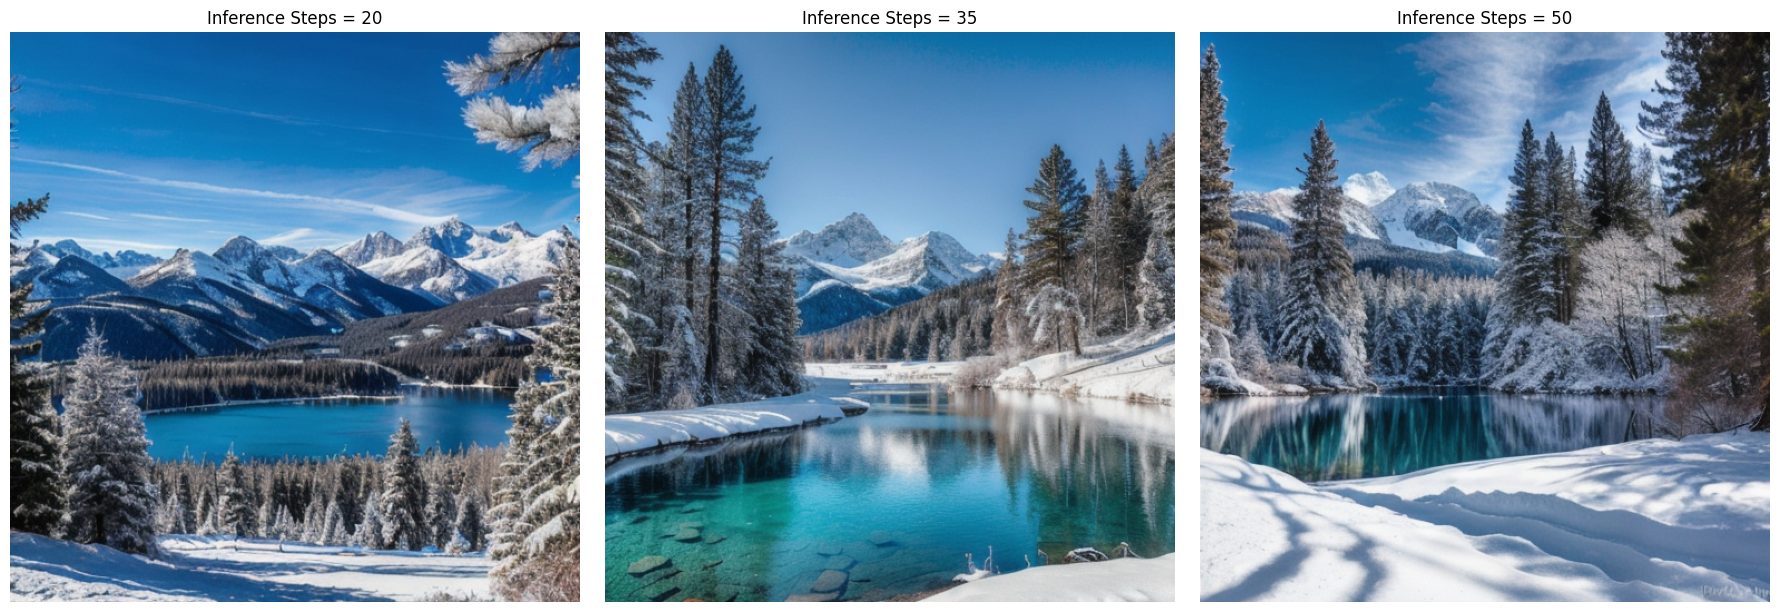

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, steps in zip(axes, [20, 35, 50]):
    ax.imshow(evaluation_results[steps])
    ax.set_title(f"Inference Steps = {steps}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
import time

evaluation_times = {}

for steps in [20, 35, 50]:
    start_time = time.time()

    _ = generate_image(
        evaluation_prompt,
        num_inference_steps=steps,
        guidance_scale=7.5
    )

    elapsed = time.time() - start_time
    evaluation_times[steps] = elapsed

    print(f"{steps} steps → {elapsed:.2f} seconds")

print("\nEvaluation timing completed!")

  0%|          | 0/20 [00:00<?, ?it/s]

Generation completed in 3.25 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 20
Guidance scale: 7.5
20 steps → 3.25 seconds


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.42 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 35
Guidance scale: 7.5
35 steps → 5.42 seconds


  0%|          | 0/50 [00:00<?, ?it/s]

Generation completed in 7.79 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 50
Guidance scale: 7.5
50 steps → 7.79 seconds

Evaluation timing completed!


In [17]:
import time
import io
import contextlib

evaluation_times = {}

for steps in [20, 35, 50]:
    start_time = time.time()

    # Hide the internal print statements from generate_image()
    with contextlib.redirect_stdout(io.StringIO()):
        _ = generate_image(
            evaluation_prompt,
            num_inference_steps=steps,
            guidance_scale=7.5
        )

    elapsed = time.time() - start_time
    evaluation_times[steps] = elapsed

    print(f"{steps} steps → {elapsed:.2f} seconds")

print("\nAll evaluation timings:")
for steps, seconds in evaluation_times.items():
    print(f"{steps} steps: {seconds:.2f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

20 steps → 3.29 seconds


  0%|          | 0/50 [00:00<?, ?it/s]

35 steps → 5.52 seconds
50 steps → 7.93 seconds

All evaluation timings:
20 steps: 3.29 seconds
35 steps: 5.52 seconds
50 steps: 7.93 seconds


In [18]:
guidance_results = {}

guidance_prompt = (
    "A photorealistic landscape of snow-covered mountains "
    "beside a crystal-clear blue lake, green pine trees, "
    "natural daylight, cinematic photography"
)

for guidance in [5.0, 7.5, 10.0]:

    print(f"Generating with guidance scale = {guidance}...")

    image = generate_image(
        guidance_prompt,
        num_inference_steps=35,
        guidance_scale=guidance
    )

    guidance_results[guidance] = image

print("Guidance scale evaluation completed!")

Generating with guidance scale = 5.0...


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.44 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 35
Guidance scale: 5.0
Generating with guidance scale = 7.5...


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.47 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 35
Guidance scale: 7.5
Generating with guidance scale = 10.0...


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.53 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 35
Guidance scale: 10.0
Guidance scale evaluation completed!


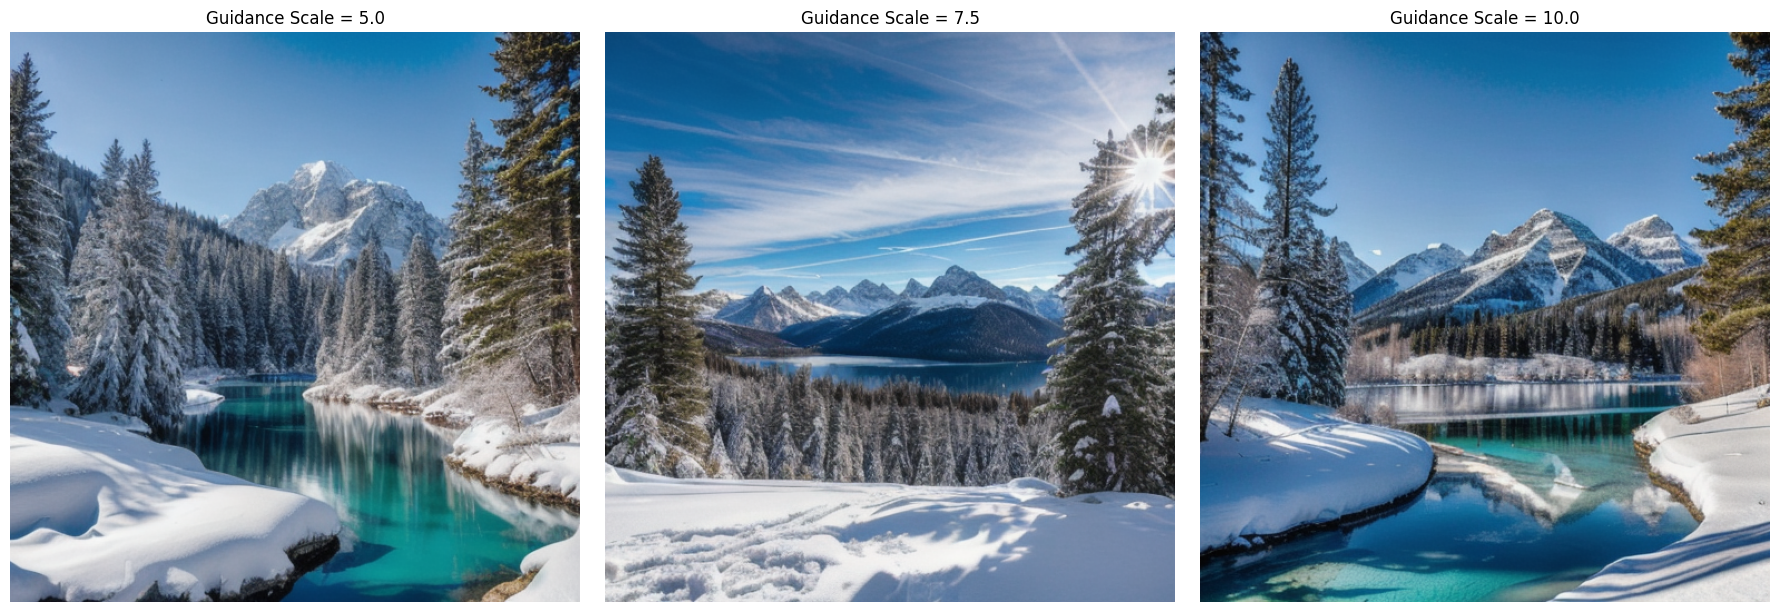

  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.40 seconds
Original prompt: A futuristic city at night with glowing neon buildings, flying cars, wet streets reflecting colorful lights, cinematic atmosphere, photorealistic
Inference steps: 35
Guidance scale: 7.5


In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, guidance in zip(axes, [5.0, 7.5, 10.0]):
    ax.imshow(guidance_results[guidance])
    ax.set_title(f"Guidance Scale = {guidance}")
    ax.axis("off")

plt.tight_layout()
plt.show()

  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 6.09 seconds
Original prompt: A photorealistic portrait of a young woman standing in a beautiful flower garden at golden hour
Inference steps: 35
Guidance scale: 7.5


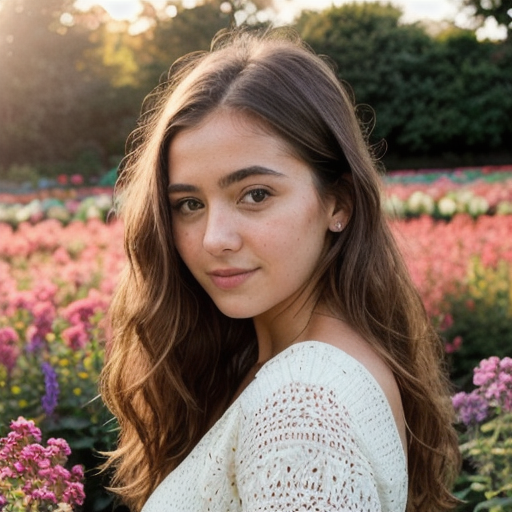

In [17]:
test_prompt = (
    "A photorealistic portrait of a young woman "
    "standing in a beautiful flower garden at golden hour"
)

result = generate_image(
    test_prompt,
    num_inference_steps=35,
    guidance_scale=7.5
)

display(result)

In [7]:
import gradio as gr

def generate_for_app(prompt, inference_steps, guidance):
    return generate_image(
        prompt,
        num_inference_steps=int(inference_steps),
        guidance_scale=float(guidance)
    )


demo = gr.Interface(
    fn=generate_for_app,

    inputs=[
        gr.Textbox(
            label="Enter your prompt",
            placeholder="Describe the image you want to generate...",
            lines=3
        ),

        gr.Slider(
            minimum=20,
            maximum=50,
            value=35,
            step=1,
            label="Inference Steps"
        ),

        gr.Slider(
            minimum=5,
            maximum=12,
            value=7.5,
            step=0.5,
            label="Guidance Scale"
        )
    ],

    outputs=gr.Image(
        label="Generated Image",
        type="pil"
    ),

    title="🖼️ Stable Diffusion Text-to-Image Generator",

    description=(
        "Generate photorealistic images using Stable Diffusion "
        "with Realistic Vision V5.1 on a Tesla T4 GPU. "
        "Experiment with different prompts and generation "
        "settings to observe the effect of prompt engineering."
    ),

    examples=[
        [
            "A photorealistic portrait of a young woman in a flower garden at golden hour",
            35,
            7.5
        ],
        [
            "A futuristic city at night with neon lights and flying cars",
            35,
            7.5
        ],
        [
            "A majestic white horse running through a green meadow",
            35,
            7.5
        ],
        [
            "A beautiful mountain landscape with a crystal-clear lake",
            35,
            7.5
        ],
        [
            "A cute golden retriever puppy playing in a sunny park",
            35,
            7.5
        ]
    ],

    cache_examples=False
)

print("Gradio interface created successfully!")

Gradio interface created successfully!


In [8]:
demo.launch(
    server_name="0.0.0.0",
    server_port=7860,
    share=False,
    prevent_thread_lock=True
)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.


In [9]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O /usr/local/bin/cloudflared
!chmod +x /usr/local/bin/cloudflared
print("Cloudflare Tunnel installed successfully!")

Cloudflare Tunnel installed successfully!


In [10]:
import subprocess
import time

cloudflared_process = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:7860"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

for _ in range(20):
    line = cloudflared_process.stdout.readline()
    if line:
        print(line.strip())

2026-10-05T10:12:57Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-10-05T10:12:57Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-10-05T10:13:01Z INF +--------------------------------------------------------------------------------------------+
2026-10-05T10:13:01Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-10-05T10:13:01Z INF |  https://port-hours-movie-miles.trycloudflare.com     

  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 6.76 seconds
Original prompt: A photorealistic portrait of a young woman standing in a beautiful flower garden at golden hour
Inference steps: 35
Guidance scale: 7.5


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (83 > 77). Running this sequence through the model will result in indexing errors
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CLIPTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', professional photography , lifelike appearance']


  0%|          | 0/35 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.46 seconds
Original prompt: A photorealistic adorable baby lying safely on their tummy on a soft white blanket, cute round face, big expressive dark eyes, small button nose, chubby cheeks, tiny hands resting together, soft dark baby hair, sweet innocent smile with slightly open mouth, natural baby skin texture, realistic facial proportions, soft natural skin tones, cozy bright bedroom, gentle daylight coming through a window, warm peaceful atmosphere, professional newborn photography, 85mm DSLR photography, shallow depth of field, soft background bokeh, sharp detailed face, highly realistic, lifelike photograph
Inference steps: 35
Guidance scale: 7.5


The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['warm peaceful atmosphere , professional newborn photography , 8 5 mm dslr photography , shallow depth of field , soft background bokeh , sharp detailed face , highly realistic , lifelike photograph , photorealistic baby , realistic natural baby face , natural facial proportions , realistic skin texture , natural eyes , natural hair , authentic baby anatomy , soft natural lighting , professional photography , highly detailed , lifelike']


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.55 seconds
Original prompt: A photorealistic adorable baby lying safely on their tummy on a soft white blanket, cute round face, big expressive dark eyes, small button nose, chubby cheeks, tiny hands resting together, soft dark baby hair, sweet innocent smile with slightly open mouth, natural baby skin texture, realistic facial proportions, soft natural skin tones, cozy bright bedroom, gentle daylight coming through a window, warm peaceful atmosphere, professional newborn photography, 85mm DSLR photography, shallow depth of field, soft background bokeh, sharp detailed face, highly realistic, lifelike photograph
Inference steps: 35
Guidance scale: 7.5


In [19]:
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f70d702e028d764089.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 

In [1]:
print("Gradio demo object:", demo)
print("Project model device:", pipe.device)

NameError: name 'demo' is not defined

In [2]:
print("realistic_pipe exists:", "realistic_pipe" in globals())
print("pipe exists:", "pipe" in globals())
print("generate_image exists:", "generate_image" in globals())
print("demo exists:", "demo" in globals())

realistic_pipe exists: False
pipe exists: False
generate_image exists: False
demo exists: False


In [11]:
evaluation_prompt = (
    "A photorealistic landscape of snow-covered mountains "
    "beside a crystal-clear blue lake, green pine trees, "
    "natural daylight, cinematic photography"
)

evaluation_results = {}

for steps in [20, 35, 50]:
    print(f"Generating with {steps} inference steps...")

    image = generate_image(
        evaluation_prompt,
        num_inference_steps=steps,
        guidance_scale=7.5
    )

    evaluation_results[steps] = image

print("Evaluation images generated successfully!")

Generating with 20 inference steps...


  0%|          | 0/20 [00:00<?, ?it/s]

Generation completed in 3.22 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 20
Guidance scale: 7.5
Generating with 35 inference steps...


  0%|          | 0/35 [00:00<?, ?it/s]

Generation completed in 5.34 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 35
Guidance scale: 7.5
Generating with 50 inference steps...


  0%|          | 0/50 [00:00<?, ?it/s]

Generation completed in 7.62 seconds
Original prompt: A photorealistic landscape of snow-covered mountains beside a crystal-clear blue lake, green pine trees, natural daylight, cinematic photography
Inference steps: 50
Guidance scale: 7.5
Evaluation images generated successfully!


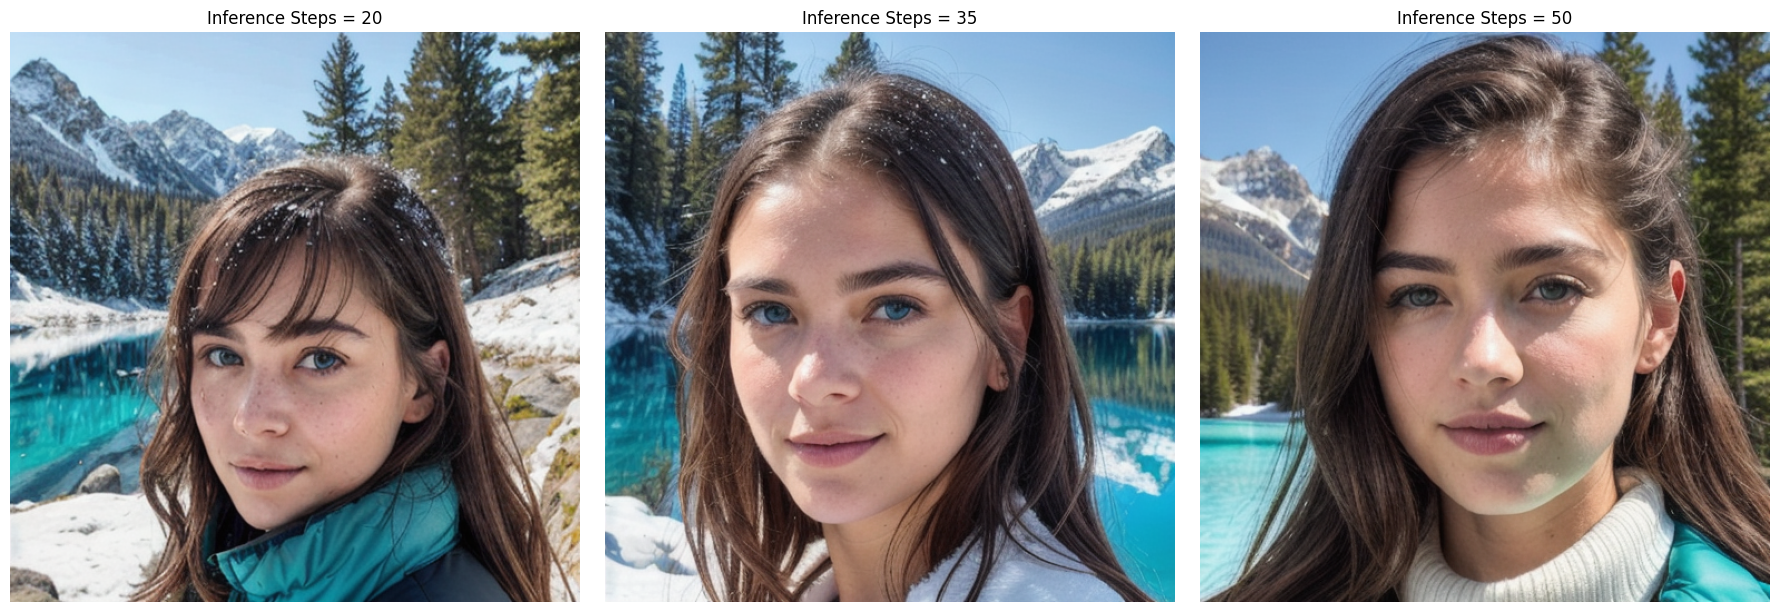

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, steps in zip(axes, [20, 35, 50]):
    ax.imshow(evaluation_results[steps])
    ax.set_title(f"Inference Steps = {steps}")
    ax.axis("off")

plt.tight_layout()
plt.show()